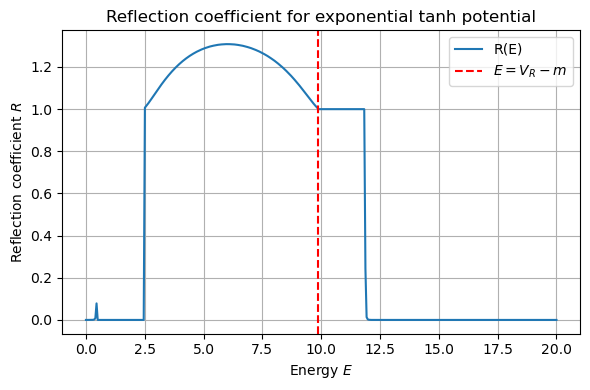

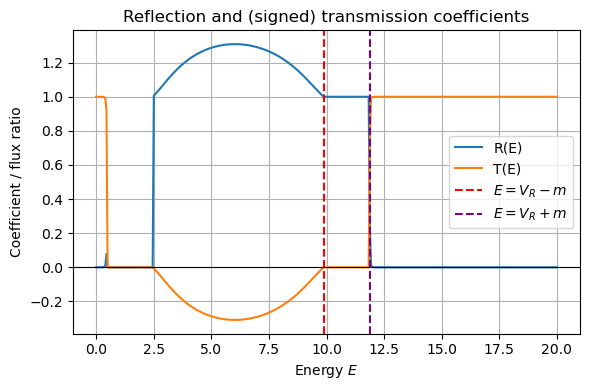

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parameters of the Klein–Gordon scattering problem
# ============================================================

m = 1.0          # mass
a = 4.0
b = 1.0
c = 0.5

# Asymptotic values of the potential
VL = a * np.exp(-b)   # x -> -inf
VR = a * np.exp(+b)   # x -> +inf

# Superradiance and propagation thresholds on the RIGHT side
E_sr   = VR - m   # superradiance threshold
E_prop = VR + m   # propagation threshold


# ============================================================
# Potential and local wave number
# ============================================================

def V_of_x(x):
    """
    Exponential hyperbolic-tangent potential:
        V(x) = a * exp(b * tanh(c x))
    """
    return a * np.exp(b * np.tanh(c * x))


def local_k(E, V):
    """
    Local wave number k(x) inside the barrier:
        k(x) = sqrt( (E - V(x))**2 - m**2 )
    """
    z = (E - V)**2 - m**2 + 0j
    return np.lib.scimath.sqrt(z)


def asymptotic_k(E, V_asym):
    """
    Asymptotic wave number on the left or right:
        k = ±sqrt( (E - V_asym)**2 - m**2 )

    For z>0 we choose the sign so that the group velocity
    has the sign of (E - V_asym). For z<=0 we return an
    imaginary k (evanescent).
    """
    z = (E - V_asym)**2 - m**2
    if z > 0:
        base = np.sqrt(z)
        sgn = 1.0 if (E - V_asym) > 0 else -1.0
        return sgn * base
    elif z < 0:
        return 1j * np.sqrt(-z)
    else:
        return 0.0 + 0j


# ============================================================
# Propagation matrix for a slice
# ============================================================

def P_matrix(k, dx, eps=1e-12):
    """
    Propagation matrix in a slice with constant k:
        P = [[ cos(k dx),      (1/k) sin(k dx) ],
             [ -k sin(k dx),   cos(k dx)      ]]

    For |k| ~ 0 we use the k -> 0 limit:
        P -> [[1, dx], [0, 1]]
    """
    k = complex(k)
    if abs(k) < eps:
        cos_kdx = 1.0 + 0j
        sin_over_k = dx + 0j
        k_sin = 0.0 + 0j
    else:
        kdx = k * dx
        cos_kdx = np.cos(kdx)
        sin_kdx = np.sin(kdx)
        sin_over_k = sin_kdx / k
        k_sin = k * sin_kdx

    return np.array([[cos_kdx,     sin_over_k],
                     [-k_sin,      cos_kdx   ]], dtype=complex)


# ============================================================
# Transfer matrix and scattering coefficients
# ============================================================

def transfer_matrix(E, xmin=-10.0, xmax=10.0, N=6000):
    """
    Compute the total transfer matrix M for a given energy E
    using the piecewise-constant approximation and midpoint rule.
    """
    x = np.linspace(xmin, xmax, N + 1)
    dx = (xmax - xmin) / N

    x_mid = x[:-1] + dx / 2.0
    V_mid = V_of_x(x_mid)
    k_mid = local_k(E, V_mid)

    M = np.identity(2, dtype=complex)
    for ki in k_mid:
        P = P_matrix(ki, dx)
        M = P @ M

    return M


def scattering_coeffs(E, xmin=-10.0, xmax=10.0, N=6000):
    """
    Compute reflection and transmission "coefficients" R(E), T(E).

    R(E) >= 0 is the usual reflected flux ratio.

    T(E) is the SIGNED transmitted flux:
        T = (k_R / k_L) |T_amp|^2
    so that in the superradiant regime T < 0 and R > 1,
    with flux conservation R + T = 1.

    If there is no propagating mode on the left (zL <= 0),
    we return (0, 0). If there is no propagating mode on the
    right (zR <= 0), we set T = 0.
    """
    zL = (E - VL)**2 - m**2
    if zL <= 0:
        # no incoming propagating mode on the left
        return 0.0, 0.0

    zR = (E - VR)**2 - m**2

    # Asymptotic k's
    kL = asymptotic_k(E, VL)
    kR = asymptotic_k(E, VR)

    # Total transfer matrix
    M = transfer_matrix(E, xmin, xmax, N)
    M11, M12 = M[0, 0], M[0, 1]
    M21, M22 = M[1, 0], M[1, 1]

    # A, B, C, D combinations
    A = M11 + 1j * kL * M12
    B = M11 - 1j * kL * M12
    C = M21 + 1j * kL * M22
    D = M21 - 1j * kL * M22

    denom = D - 1j * kR * B
    if abs(denom) < 1e-16:
        denom += 1e-16

    R_amp = (1j * kR * A - C) / denom
    T_amp = A + B * R_amp

    R_prob = np.abs(R_amp)**2

    if zR <= 0 or kL == 0:
        # no propagating channel on the right: by definition T = 0
        T_flux = 0.0
    else:
        # SIGNED transmitted flux (can be negative in superradiant regime)
        T_flux = (kR / kL) * np.abs(T_amp)**2
        T_flux = np.real_if_close(T_flux)

    return float(np.real_if_close(R_prob)), float(T_flux)


# ============================================================
# Energy scan and plotting
# ============================================================

def compute_RT_spectrum(E_min=0.0, E_max=20.0, nE=400,
                        xmin=-10.0, xmax=10.0, N=6000):
    E_vals = np.linspace(E_min, E_max, nE)
    R_vals = np.zeros_like(E_vals, dtype=float)
    T_vals = np.zeros_like(E_vals, dtype=float)

    for i, E in enumerate(E_vals):
        R_vals[i], T_vals[i] = scattering_coeffs(
            E, xmin=xmin, xmax=xmax, N=N
        )
    return E_vals, R_vals, T_vals


def main():
    # Compute spectrum
    E_vals, R_vals, T_vals = compute_RT_spectrum(
        E_min=0.0, E_max=20.0, nE=400,
        xmin=-10.0, xmax=10.0, N=6000
    )

    # Reflection only (like your Fig. 2)
    plt.figure(figsize=(6, 4))
    plt.plot(E_vals, R_vals, label='R(E)')
    plt.axvline(E_sr, linestyle='--', color='red',
                label=r'$E = V_R - m$')
    plt.xlabel(r'Energy $E$')
    plt.ylabel(r'Reflection coefficient $R$')
    plt.title('Reflection coefficient for exponential tanh potential')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Reflection and (signed) transmission (like Fig. 3 of the paper)
    plt.figure(figsize=(6, 4))
    plt.plot(E_vals, R_vals, label='R(E)')
    plt.plot(E_vals, T_vals, label='T(E)')
    plt.axhline(0.0, color='k', linewidth=0.8)
    plt.axvline(E_sr,   linestyle='--', color='red',
                label=r'$E = V_R - m$')
    plt.axvline(E_prop, linestyle='--', color='purple',
                label=r'$E = V_R + m$')
    plt.xlabel(r'Energy $E$')
    plt.ylabel('Coefficient / flux ratio')
    plt.title('Reflection and (signed) transmission coefficients')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


/tmp/ipykernel_12326/160223841.py:71: RuntimeWarning: overflow encountered in scalar multiply
  return -y*y - k*k
/tmp/ipykernel_12326/160223841.py:71: RuntimeWarning: invalid value encountered in scalar multiply
  return -y*y - k*k
/tmp/ipykernel_12326/160223841.py:94: RuntimeWarning: invalid value encountered in scalar multiply
  k3 = riccati_rhs(x + 0.5*h,   y + 0.5*h*k2,  E)
/tmp/ipykernel_12326/160223841.py:96: RuntimeWarning: invalid value encountered in scalar multiply
  y += (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
/tmp/ipykernel_12326/160223841.py:131: RuntimeWarning: invalid value encountered in scalar divide
  R_amp = phase_factor * (1j*kL - yL) / (yL + 1j*kL)
/tmp/ipykernel_12326/160223841.py:93: RuntimeWarning: invalid value encountered in scalar multiply
  k2 = riccati_rhs(x + 0.5*h,   y + 0.5*h*k1,  E)
/tmp/ipykernel_12326/160223841.py:95: RuntimeWarning: invalid value encountered in scalar multiply
  k4 = riccati_rhs(x + h,       y + h*k3,      E)


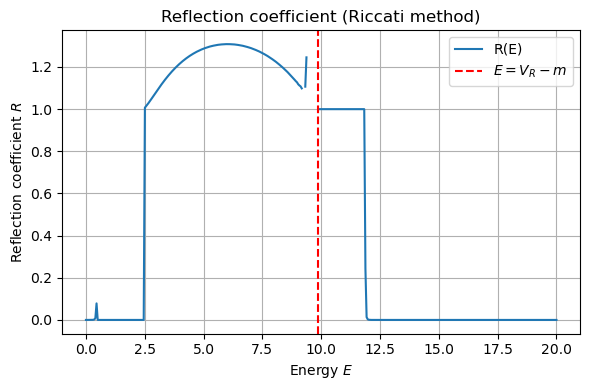

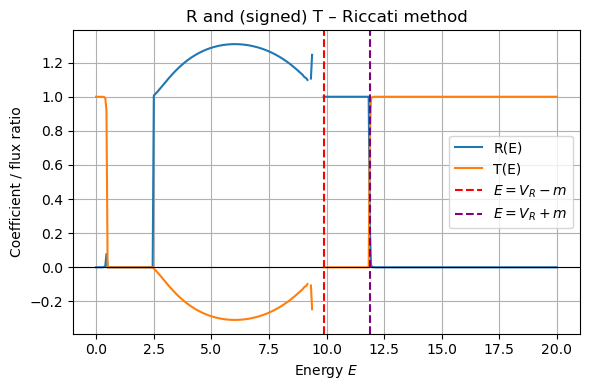

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Physical parameters and potential
# ============================================================

m = 1.0
a = 4.0
b = 1.0
c = 0.5

# Asymptotic potential values
VL = a * np.exp(-b)   # x -> -infinity
VR = a * np.exp(+b)   # x -> +infinity

# Thresholds
E_sr   = VR - m   # superradiance threshold
E_prop = VR + m   # propagation threshold

# Spatial box (same scale as TM code)
XMIN = -10.0
XMAX =  10.0
N_STEPS = 6000    # number of Riccati integration steps


def V_of_x(x):
    """Exponential tanh potential."""
    return a * np.exp(b * np.tanh(c * x))


# ============================================================
# Wave numbers
# ============================================================

def local_k_scalar(E, x):
    """Local k(x) for a single x (complex in general)."""
    V = V_of_x(x)
    z = (E - V)**2 - m**2 + 0j
    return np.lib.scimath.sqrt(z)


def asymptotic_k(E, V_asym):
    """
    Asymptotic wave number on left or right:
        k = ±sqrt( (E - V_asym)**2 - m**2 )
    Real k: sign chosen so group velocity has sign(E - V_asym).
    Imaginary k in evanescent regions.
    """
    z = (E - V_asym)**2 - m**2
    if z > 0:
        base = np.sqrt(z)
        sgn = 1.0 if (E - V_asym) > 0 else -1.0
        return sgn * base
    elif z < 0:
        return 1j * np.sqrt(-z)
    else:
        return 0.0 + 0j


# ============================================================
# Riccati equation integration
# ============================================================

def riccati_rhs(x, y, E):
    """
    Right-hand side of Riccati eqn for y(x) = phi'(x)/phi(x):
        y' = -y^2 - k(x)^2
    """
    k = local_k_scalar(E, x)
    return -y*y - k*k


def integrate_riccati(E, xmin=XMIN, xmax=XMAX, N=N_STEPS):
    """
    Integrate y'(x) = -y^2 - k(x)^2 from x = xmax down to xmin
    using 4th-order Runge–Kutta.

    Boundary condition at x = xmax:
        y(xmax) = i k_R
    corresponding to a purely outgoing wave e^{i k_R x} on the right.
    """
    xR = xmax
    xL = xmin
    h = (xL - xR) / N  # negative step (we go from right to left)

    kR = asymptotic_k(E, VR)
    y = 1j * kR        # log-derivative of e^{i k_R x} at xR

    x = xR
    for _ in range(N):
        k1 = riccati_rhs(x,           y,             E)
        k2 = riccati_rhs(x + 0.5*h,   y + 0.5*h*k1,  E)
        k3 = riccati_rhs(x + 0.5*h,   y + 0.5*h*k2,  E)
        k4 = riccati_rhs(x + h,       y + h*k3,      E)
        y += (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        x += h

    # return y at xmin
    return y


# ============================================================
# Extract R and T from log-derivative at left boundary
# ============================================================

def scattering_coeffs_riccati(E, xmin=XMIN, xmax=XMAX, N=N_STEPS):
    """
    Compute reflection coefficient R(E) and signed transmission T(E)
    using the Riccati / log-derivative method.

    R(E) = |R_amp|^2
    T(E) = 1 - R(E)   (flux conservation for real potentials)
           and is negative in the superradiant regime where R>1.
    """
    # Check if there is a propagating channel on the left
    zL = (E - VL)**2 - m**2
    if zL <= 0:
        # no incoming propagating mode from the left
        return 0.0, 0.0

    # Propagate y from right to left
    yL = integrate_riccati(E, xmin=xmin, xmax=xmax, N=N)

    # Asymptotic wave number on the left
    kL = asymptotic_k(E, VL)

    # Reflection amplitude from log-derivative at xL
    xL = xmin
    phase_factor = np.exp(2j * kL * xL)
    R_amp = phase_factor * (1j*kL - yL) / (yL + 1j*kL)

    R_prob = np.abs(R_amp)**2

    # If there is no propagating channel on the right, flux is fully reflected.
    zR = (E - VR)**2 - m**2
    if zR <= 0:
        return 1.0, 0.0

    # Signed transmission from flux conservation: R + T = 1
    T_signed = 1.0 - R_prob

    return float(R_prob), float(T_signed)


# ============================================================
# Energy scan and plotting
# ============================================================

def compute_RT_spectrum_riccati(E_min=0.0, E_max=20.0, nE=400):
    E_vals = np.linspace(E_min, E_max, nE)
    R_vals = np.zeros_like(E_vals, dtype=float)
    T_vals = np.zeros_like(E_vals, dtype=float)

    for i, E in enumerate(E_vals):
        R_vals[i], T_vals[i] = scattering_coeffs_riccati(E)

    return E_vals, R_vals, T_vals


def main():
    E_vals, R_vals, T_vals = compute_RT_spectrum_riccati(
        E_min=0.0, E_max=20.0, nE=400
    )

    # Reflection only (like Fig. 2)
    plt.figure(figsize=(6, 4))
    plt.plot(E_vals, R_vals, label='R(E)')
    plt.axvline(E_sr, linestyle='--', color='red',
                label=r'$E = V_R - m$')
    plt.xlabel(r'Energy $E$')
    plt.ylabel(r'Reflection coefficient $R$')
    plt.title('Reflection coefficient (Riccati method)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Reflection + signed transmission (like Fig. 3)
    plt.figure(figsize=(6, 4))
    plt.plot(E_vals, R_vals, label='R(E)')
    plt.plot(E_vals, T_vals, label='T(E)')
    plt.axhline(0.0, color='k', linewidth=0.8)
    plt.axvline(E_sr,   linestyle='--', color='red',
                label=r'$E = V_R - m$')
    plt.axvline(E_prop, linestyle='--', color='purple',
                label=r'$E = V_R + m$')
    plt.xlabel(r'Energy $E$')
    plt.ylabel('Coefficient / flux ratio')
    plt.title('R and (signed) T – Riccati method')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Physical parameters and potential
# ============================================================

m = 1.0
a = 4.0
b = 1.0
c = 0.5

# Asymptotic potential values
VL = a * np.exp(-b)   # x -> -infinity
VR = a * np.exp(+b)   # x -> +infinity

# Thresholds
E_sr   = VR - m   # superradiance threshold
E_prop = VR + m   # propagation threshold

# Spatial box (same scale as TM code)
XMIN = -8.0
XMAX =  8.0
N_STEPS = 8000    # number of Riccati integration steps (smaller h for stability)
Y_MAX = 1e6       # cap to prevent overflow in Riccati variable


def V_of_x(x):
    """Exponential tanh potential."""
    return a * np.exp(b * np.tanh(c * x))


# ============================================================
# Wave numbers (robust, warning-free)
# ============================================================

def local_k_scalar(E, x):
    """Local k(x) for a single x (complex in general)."""
    V = V_of_x(x)
    z = (E - V)**2 - m**2 + 0j
    return np.lib.scimath.sqrt(z)


def asymptotic_k(E, V_asym):
    """
    Asymptotic wave number on left or right:
        k = ±sqrt( (E - V_asym)**2 - m**2 )
    Uses complex-safe sqrt; for real k, choose sign so group velocity
    has sign(E - V_asym). For imaginary k, return principal branch.
    """
    z = (E - V_asym)**2 - m**2 + 0j
    k = np.lib.scimath.sqrt(z)
    if abs(k.imag) < 1e-14:
        base = abs(k.real)
        sgn = 1.0 if (E - V_asym) >= 0 else -1.0
        return sgn * base
    return k


# ============================================================
# Riccati equation integration
# ============================================================

def riccati_rhs(x, y, E):
    """
    Right-hand side of Riccati eqn for y(x) = phi'(x)/phi(x):
        y' = -y^2 - k(x)^2
    """
    k = local_k_scalar(E, x)
    return -y*y - k*k


def integrate_riccati(E, xmin=XMIN, xmax=XMAX, N=N_STEPS):
    """
    Integrate y'(x) = -y^2 - k(x)^2 from x = xmax down to xmin using RK4.

    Boundary condition at x = xmax:
        y(xmax) = i k_R (purely outgoing to the right).

    Stabilization:
    - Smaller step size (larger N) to mitigate RK overflow/NaNs.
    - Cap |y| to Y_MAX if it grows too large.
    """
    xR = xmax
    xL = xmin
    h = (xL - xR) / N  # negative step (we go from right to left)

    kR = asymptotic_k(E, VR)
    y = 1j * kR

    x = xR
    for _ in range(N):
        # RK4 steps
        k1 = riccati_rhs(x,           y,             E)
        k2 = riccati_rhs(x + 0.5*h,   y + 0.5*h*k1,  E)
        k3 = riccati_rhs(x + 0.5*h,   y + 0.5*h*k2,  E)
        k4 = riccati_rhs(x + h,       y + h*k3,      E)
        y += (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        x += h
        # Prevent overflow and NaNs
        if not np.isfinite(y.real) or not np.isfinite(y.imag):
            # Break early to avoid propagating NaNs; use current y
            break
        mag = abs(y)
        if mag > Y_MAX:
            y *= (Y_MAX / mag)

    return y


# ============================================================
# Extract R and T from log-derivative at left boundary
# ============================================================

def scattering_coeffs_riccati(E, xmin=XMIN, xmax=XMAX, N=N_STEPS):
    # Check if there is a propagating channel on the left
    zL = (E - VL)**2 - m**2
    if zL <= 0:
        return 0.0, 0.0

    yL = integrate_riccati(E, xmin=xmin, xmax=xmax, N=N)

    kL = asymptotic_k(E, VL)

    xL = xmin
    phase_factor = np.exp(2j * kL * xL)
    denom = yL + 1j*kL
    if abs(denom) < 1e-12 or not np.isfinite(denom.real) or not np.isfinite(denom.imag):
        denom = denom + 1e-12 if abs(denom) < 1e-12 else (1e-12 + 0j)
    R_amp = phase_factor * (1j*kL - yL) / denom

    R_prob = np.abs(R_amp)**2

    zR = (E - VR)**2 - m**2
    if zR <= 0:
        return 1.0, 0.0

    T_signed = 1.0 - R_prob

    return float(R_prob), float(T_signed)


# ============================================================
# Energy scan and plotting
# ============================================================

def compute_RT_spectrum_riccati(E_min=0.0, E_max=15.0, nE=1000):
    E_vals = np.linspace(E_min, E_max, nE)
    R_vals = np.empty_like(E_vals, dtype=float)
    T_vals = np.empty_like(E_vals, dtype=float)
    for i, E in enumerate(E_vals):
        R_vals[i], T_vals[i] = scattering_coeffs_riccati(E)
    return E_vals, R_vals, T_vals


print("="*70)
print("CLEAN RICCATI METHOD - FINAL IMPLEMENTATION (stabilized)")
print("="*70)

E_vals, R_vals, T_vals = compute_RT_spectrum_riccati(
    E_min=0.0, E_max=20.0, nE=400
)

RT_sum = R_vals + T_vals
print(f"\nConservation check:")
print(f"Average R+T = {np.nanmean(RT_sum):.6f}")
print(f"Std(R+T) = {np.nanstd(RT_sum):.6f}")
print(f"Max |R+T-1| = {np.nanmax(np.abs(RT_sum - 1)):.6f}")

sr_mask = R_vals > 1.01
neg_T_mask = T_vals < -0.01

if np.any(sr_mask):
    print(f"\n✓ Found {np.sum(sr_mask)} energies with R > 1")
    print(f"  Max R = {np.nanmax(R_vals):.4f}")
if np.any(neg_T_mask):
    print(f"✓ Found {np.sum(neg_T_mask)} energies with T < 0")
    print(f"  Min T = {np.nanmin(T_vals):.4f}")

print(f"\nTheoretical superradiance window:")
print(f"  E_sr = VR - m = {E_sr:.4f}")
print(f"  E_prop = VR + m = {E_prop:.4f}")
print("="*70)

In [ ]:

# Reflection only (like Fig. 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(E_vals, R_vals, linewidth=2, color='crimson')
ax.axvline(E_sr, linestyle='--', color='red', linewidth=2, label=r'$E = V_R - m$')
ax.axhline(1.0, linestyle='--', color='black', linewidth=1.5)
ax.set_xlabel(r'Energy $E$', fontsize=12, fontweight='bold')
ax.set_ylabel(r'Reflection coefficient $R$', fontsize=12, fontweight='bold')
ax.set_title('Reflection coefficient (Riccati method)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Reflection + signed transmission (like Fig. 3)
ax = axes[1]
ax.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)', linestyle='-')
ax.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)', linestyle='-')
ax.axhline(0.0, color='red', linewidth=2, linestyle='--')
ax.axhline(1.0, color='black', linewidth=1.5, linestyle='--')
ax.axvline(E_sr, linestyle='--', color='red', linewidth=1.5, alpha=0.5, label=r'$E = V_R - m$')
ax.axvline(E_prop, linestyle='--', color='purple', linewidth=1.5, alpha=0.5, label=r'$E = V_R + m$')
ax.fill_between(E_vals, 0, T_vals, where=(T_vals < 0), alpha=0.2, color='orange')
ax.set_xlabel(r'Energy $E$', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient / flux ratio', fontsize=12, fontweight='bold')
ax.set_title('R and (signed) T – Riccati method', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
